# Import Libraries

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

from zipfile import ZipFile
import os

# Upload ZIP Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving E-Commerce_Sales_Performance_Analysis.zip to E-Commerce_Sales_Performance_Analysis.zip


In [ ]:
# Extract ZIP File
zip_file = list(uploaded.keys())[0]

with ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [ ]:
# Check Extracted Files
os.listdir("dataset")

['ecommerce_sales_data.csv']

In [ ]:
# load it
df = pd.read_csv("/content/dataset/ecommerce_sales_data.csv")

# Dataset Overview

In [ ]:
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Year,Month,Day,Weekday
0,2024-12-31,Printer,Office,North,4,3640,348.93,2024,December,31,Tuesday
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,2022,November,27,Sunday
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,2022,May,11,Wednesday
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,2024,March,16,Saturday
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,2022,September,10,Saturday


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[ns]
 1   Product Name  3500 non-null   object        
 2   Category      3500 non-null   object        
 3   Region        3500 non-null   object        
 4   Quantity      3500 non-null   int64         
 5   Sales         3500 non-null   int64         
 6   Profit        3500 non-null   float64       
 7   Year          3500 non-null   int32         
 8   Month         3500 non-null   object        
 9   Day           3500 non-null   int32         
 10  Weekday       3500 non-null   object        
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2), object(5)
memory usage: 273.6+ KB


In [ ]:
df.shape

(3500, 11)

In [ ]:
df.describe()

,Order Date,Quantity,Sales,Profit,Year,Day
count,3500,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,2023-07-13 00:53:53.828571648,4.931714,3047.966000,527.047203,2023.030857,15.639714
min,2022-01-01 00:00:00,1.000000,51.000000,6.970000,2022.000000,1.000000
25%,2022-10-16 18:00:00,3.000000,1049.500000,158.695000,2022.000000,8.000000
50%,2023-07-21 12:00:00,5.000000,2350.500000,361.070000,2023.000000,16.000000
75%,2024-04-16 06:00:00,7.000000,4537.000000,729.125000,2024.000000,23.000000
max,2024-12-31 00:00:00,9.000000,10782.000000,2946.930000,2024.000000,31.000000
std,NaN,2.575895,2440.213237,504.139732,0.809466,8.716989


In [ ]:
df.isnull().sum()

,0
Order Date,0
Product Name,0
Category,0
Region,0
Quantity,0
Sales,0
Profit,0
Year,0
Month,0
Day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Convert Date Column

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Feature Engineering

In [ ]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month_name()

df["Month Number"] = df["Order Date"].dt.month

df["Day"] = df["Order Date"].dt.day

df["Weekday"] = df["Order Date"].dt.day_name()

df["Quarter"] = df["Order Date"].dt.quarter

# Correlation Heatmap

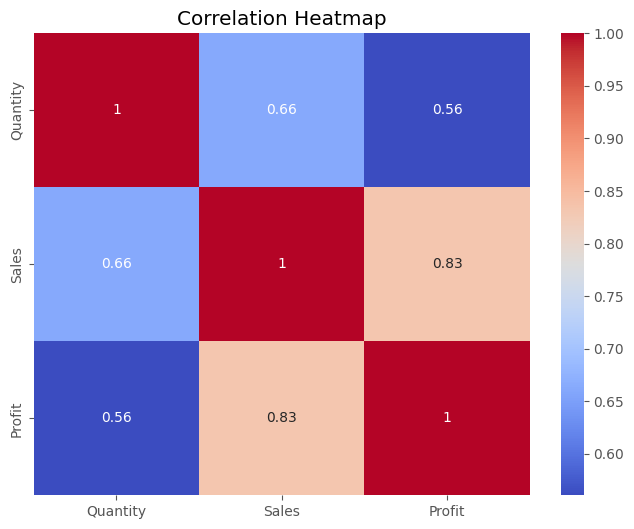

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df[["Quantity","Sales","Profit"]].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Sales Distribution

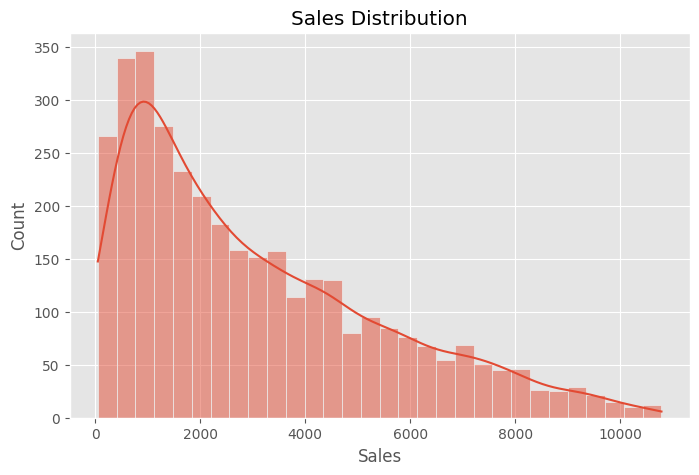

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Sales Distribution")

plt.show()

# Profit Distribution

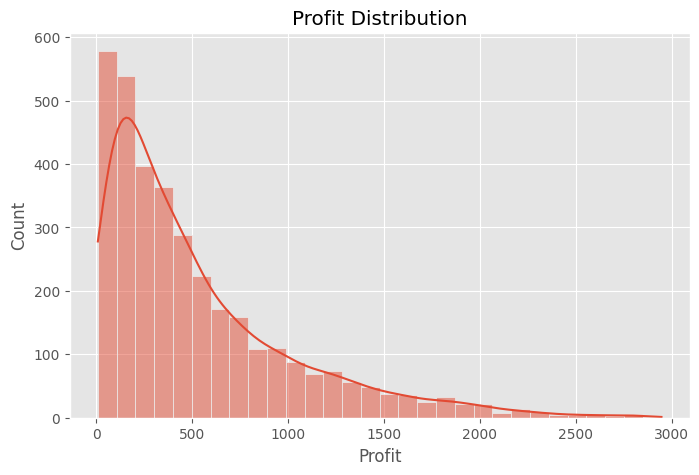

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Profit"], bins=30, kde=True)

plt.title("Profit Distribution")

plt.show()

# Quantity Distribution

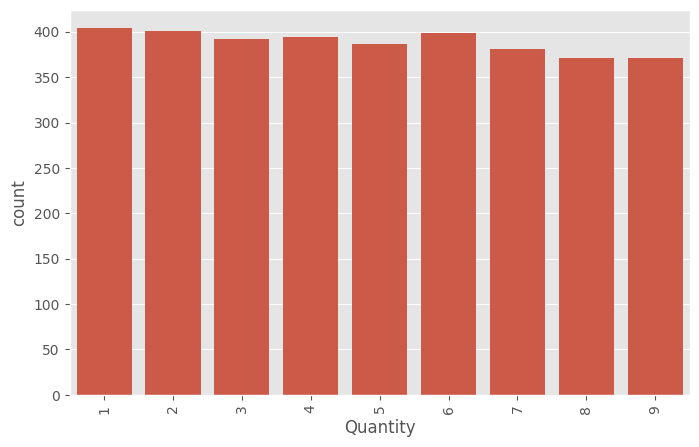

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x="Quantity", data=df)

plt.xticks(rotation=90)

plt.show()

# Monthly Sales

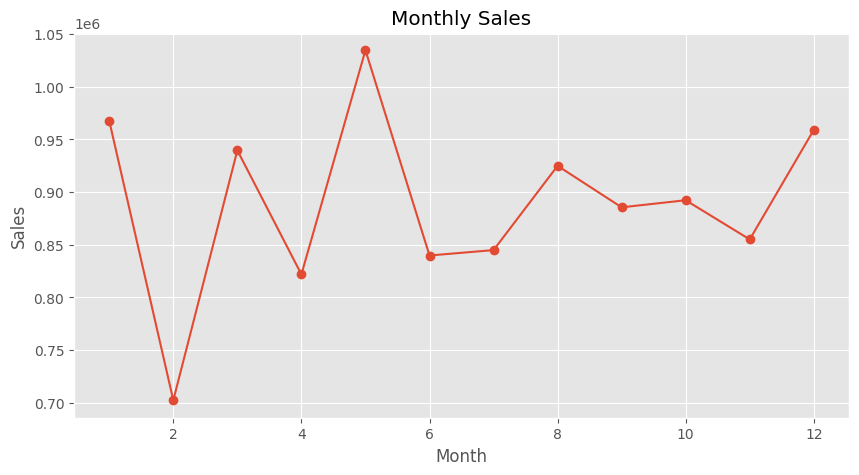

In [ ]:
monthly_sales = df.groupby("Month Number")["Sales"].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

# Monthly Profit

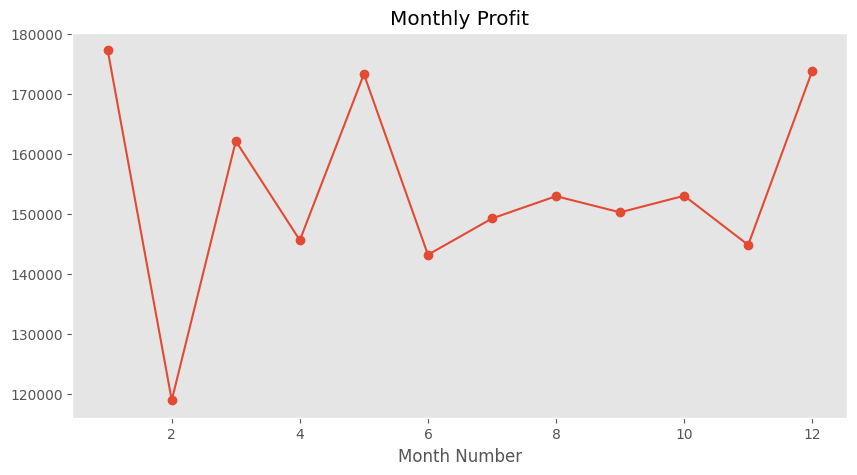

In [ ]:
monthly_profit = df.groupby("Month Number")["Profit"].sum()

plt.figure(figsize=(10,5))

monthly_profit.plot(marker="o")

plt.title("Monthly Profit")

plt.grid()

plt.show()

# Yearly Sales

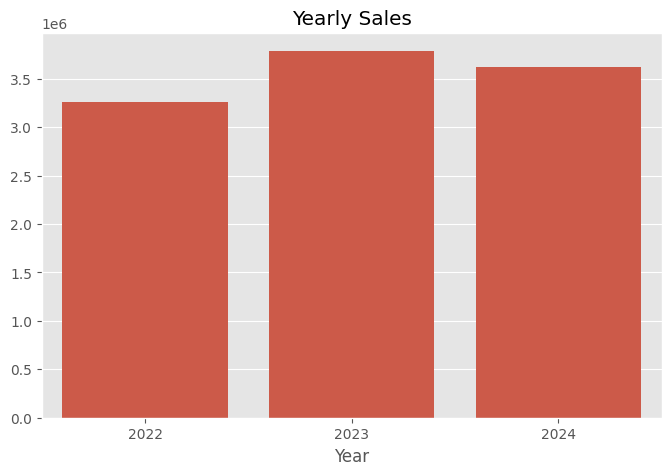

In [ ]:
year_sales = df.groupby("Year")["Sales"].sum()

plt.figure(figsize=(8,5))

sns.barplot(x=year_sales.index,
            y=year_sales.values)

plt.title("Yearly Sales")

plt.show()

# Sales by Region

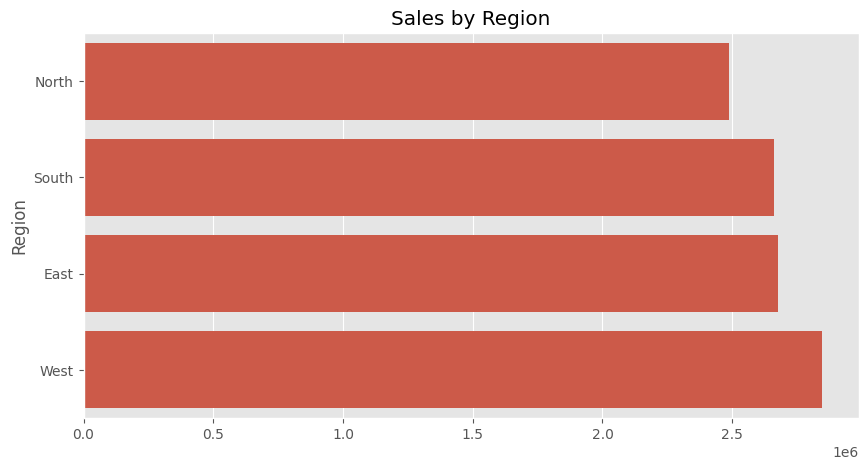

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

plt.figure(figsize=(10,5))

sns.barplot(x=region_sales.values,
            y=region_sales.index)

plt.title("Sales by Region")

plt.show()

# Sales by Category

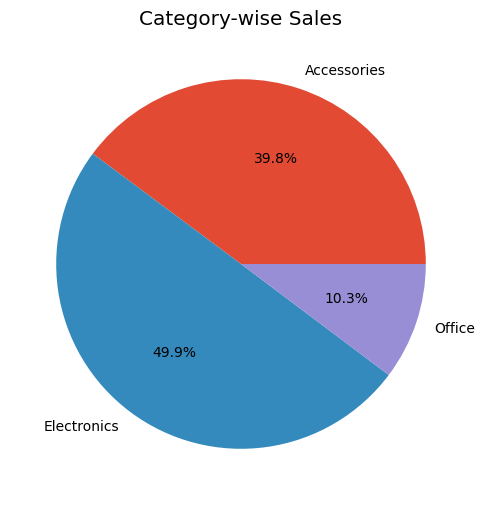

In [ ]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,6))

category_sales.plot(kind="pie",
                    autopct="%1.1f%%")

plt.ylabel("")

plt.title("Category-wise Sales")

plt.show()

# Profit by Category

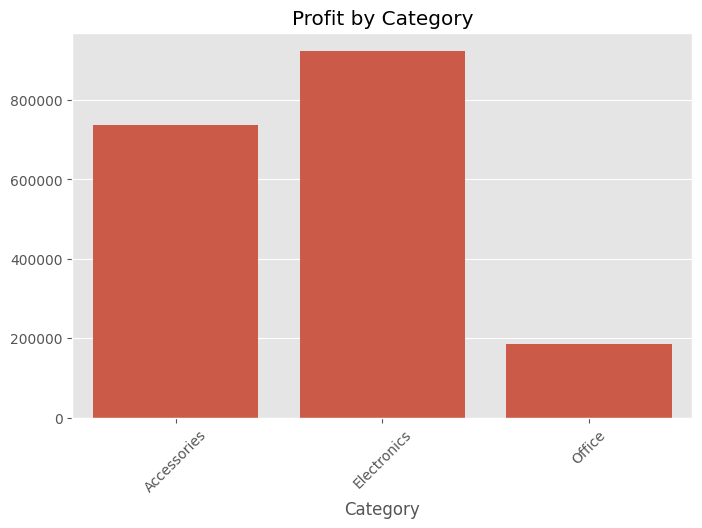

In [ ]:
category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))

sns.barplot(x=category_profit.index,
            y=category_profit.values)

plt.xticks(rotation=45)

plt.title("Profit by Category")

plt.show()

# Top 10 Products by Sales

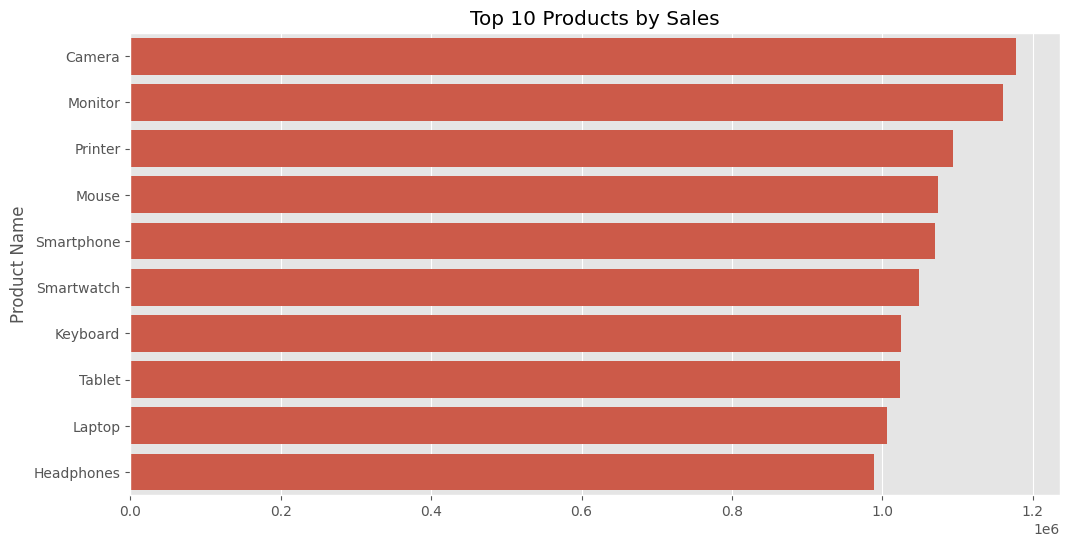

In [ ]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_products.values,
            y=top_products.index)

plt.title("Top 10 Products by Sales")

plt.show()

# Top 10 Products by Profit

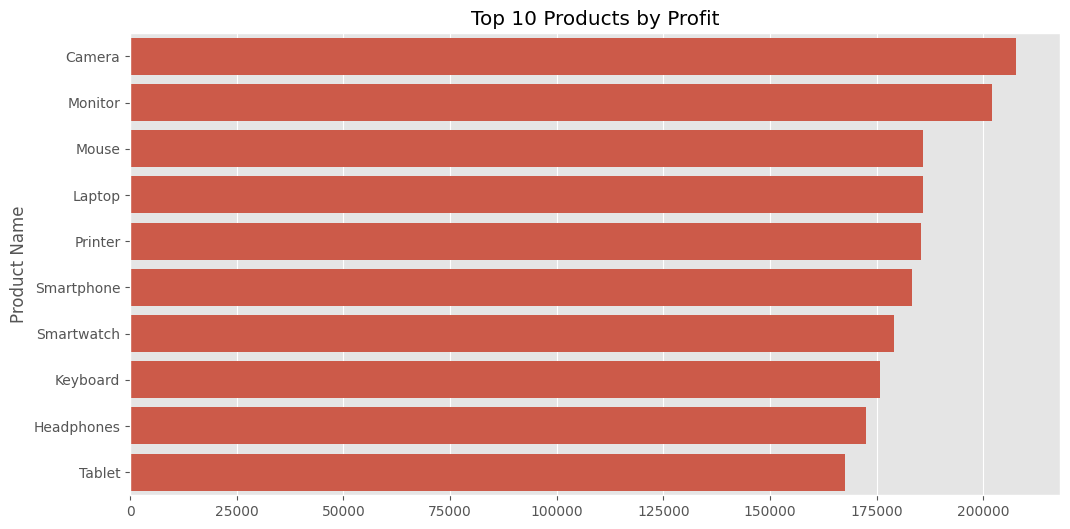

In [ ]:
top_profit = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_profit.values,
            y=top_profit.index)

plt.title("Top 10 Products by Profit")

plt.show()

# Top Selling Categories

In [ ]:
df.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

,Quantity
Category,
Electronics,8610
Accessories,6917
Office,1734


# Sales vs Profit

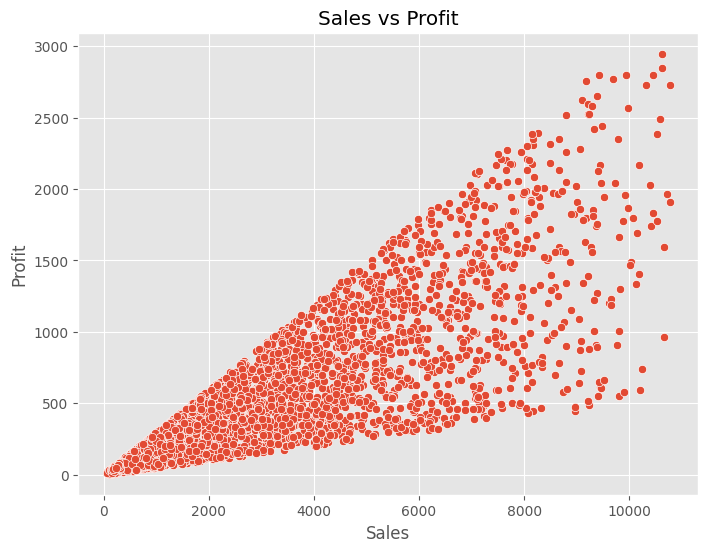

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="Sales",
                y="Profit")

plt.title("Sales vs Profit")

plt.show()

# Boxplots

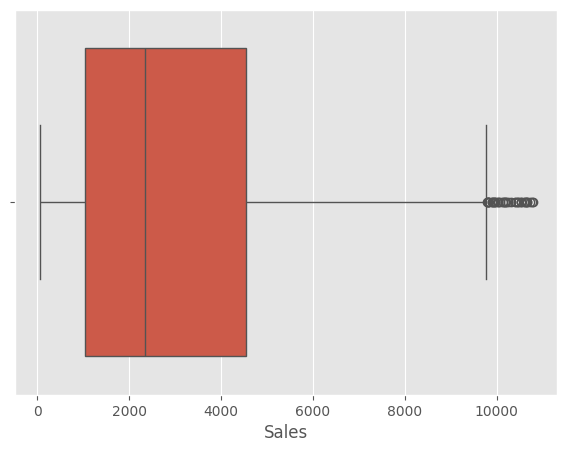

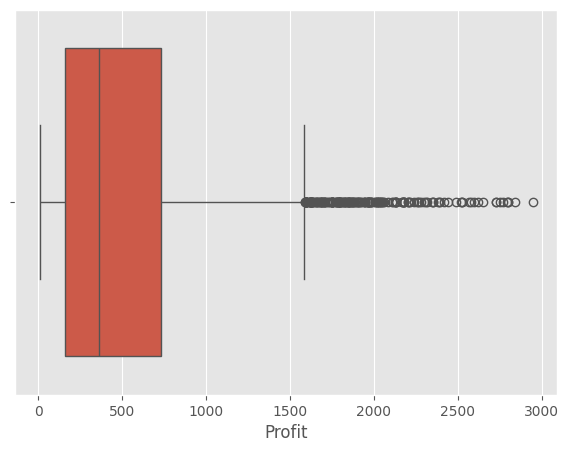

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(x=df["Sales"])

plt.show()

plt.figure(figsize=(7,5))

sns.boxplot(x=df["Profit"])

plt.show()

# Pairplot

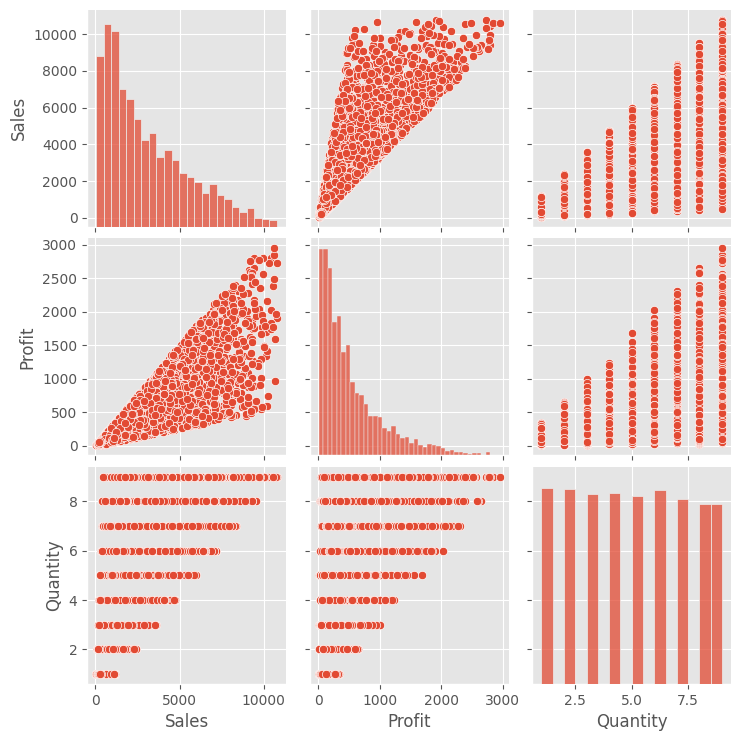

In [ ]:
sns.pairplot(df[["Sales","Profit","Quantity"]])

plt.show()

# Save Clean Dataset

In [ ]:
df.to_csv("cleaned_ecommerce_sales.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
